# Customer Churn Analysis - Week 1 EDA
**Author**: Rubab Qaiser
**Date**: March 3,2026
**Course**:Introduction to Applied AI

## Project Overview
This project analyzes the Telco Customer Churn dataset to identify key factors driving customer attrition using exploratory data analysis and correlation studies.

## Tables of Content
1.Dataset Overview
2.Numerical Features Analysis
3.Categorical Features
4.Feature Correlations
5.Key Insights and Findings

In [41]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#setting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize']=(10,6)
%matplotlib inline
print('Libraries imported succesfully!')

Libraries imported succesfully!


In [43]:
data=pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Dataset shape:", data.shape)
data.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [44]:
#Columns information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [45]:
#statistical summary
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [46]:
#check missing values
print('Missing values')
print(data.isnull().sum())

Missing values
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [47]:
#fix total charges if needed
data['TotalCharges']=pd.to_numeric(data['TotalCharges'], errors='coerce')

In [48]:
#Target Variable Distribution
print('Churn Distribution:')
print(data['Churn'].value_counts())
print('Churn Percentage')
print(data['Churn'].value_counts(normalize=True)*100)

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn Percentage
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


### Key Findings
-Dataset has X customers
-Churn rate is Y%
-Z missing values in TotalCharges column
-Features include demographic, services, account info

### Numerical Features Analysis

### Tenure Distribution

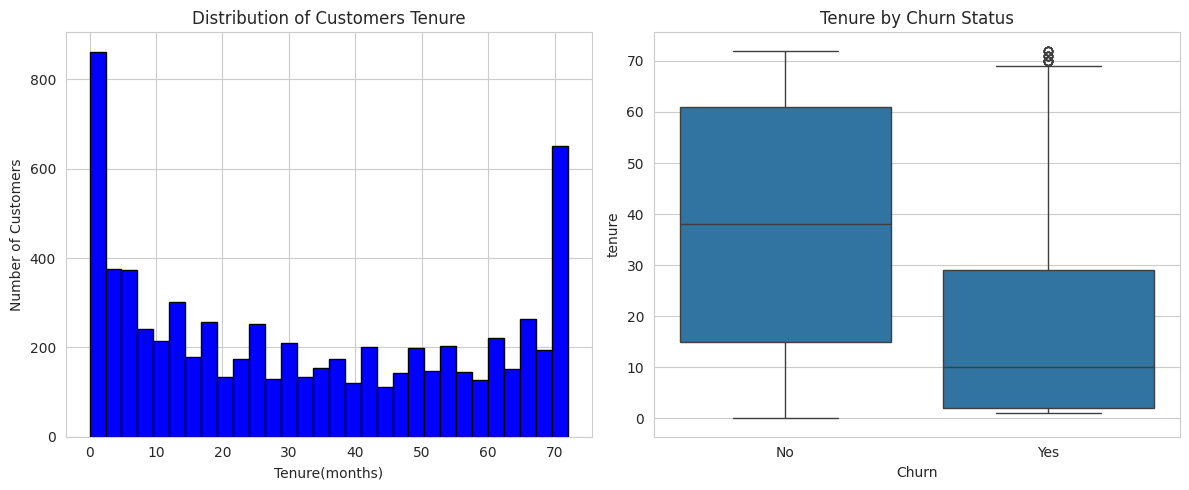

In [49]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
#histogram is the distribution of a single variable
plt.hist(data['tenure'], bins=30, color='blue', edgecolor='black')
plt.xlabel("Tenure(months)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customers Tenure")
plt.subplot(1,2,2)
sns.boxplot(x='Churn',y='tenure', data=data)
plt.title("Tenure by Churn Status")
plt.tight_layout()
plt.show()

### Monthly Charges

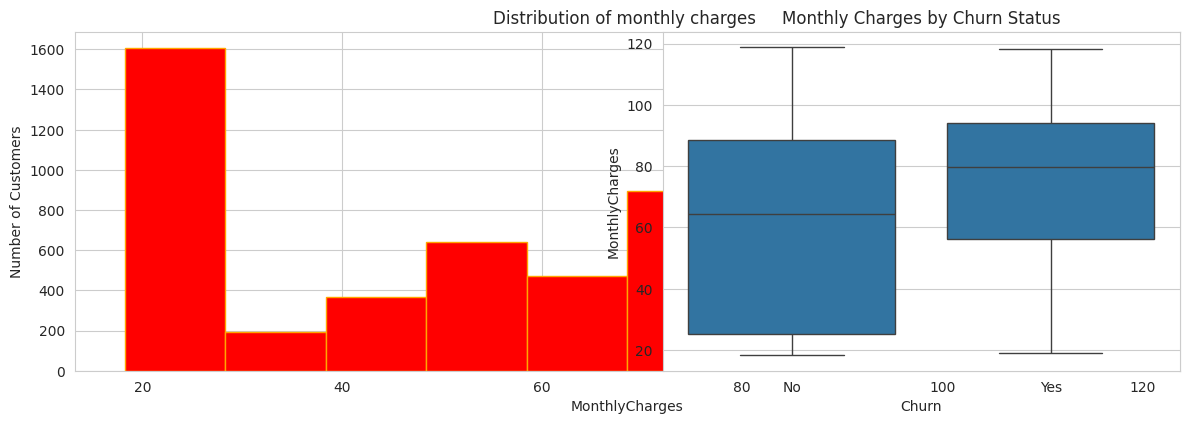

In [50]:
plt.figure(figsize=(12,5))
plt.hist(data['MonthlyCharges'],color='red', edgecolor='orange')
plt.xlabel('MonthlyCharges')
plt.ylabel('Number of Customers')
plt.title("Distribution of monthly charges ")
plt.subplot(1,2,2)
sns.boxplot(x='Churn',y='MonthlyCharges',data=data)
plt.title("Monthly Charges by Churn Status")
plt.tight_layout()
plt.show()

### Total Charges Analysis


In [51]:
#Remove if there are ay missing values
data_clean=data[data['TotalCharges'].notna()]
print('Data is Clean now')

Data is Clean now


Data is Cclean now


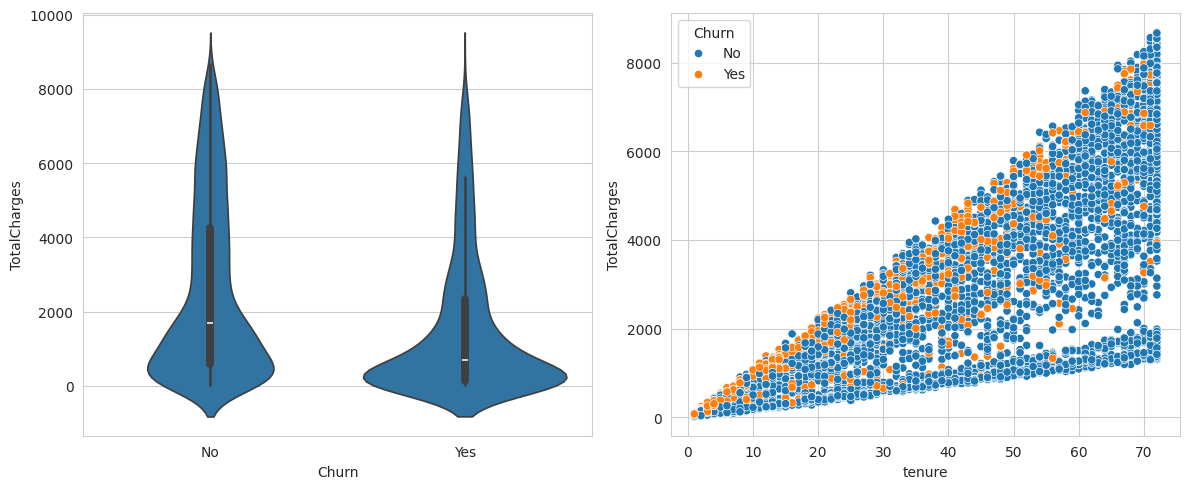

In [52]:
#Remove if there are ay missing values
data_clean=data[data['TotalCharges'].notna()]
print('Data is Cclean now')
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.violinplot(x='Churn',y='TotalCharges',data=data_clean)
plt.subplot(1,2,2)
sns.scatterplot(x='tenure',y='TotalCharges',hue='Churn',data=data_clean)
#tenure means how long the customers have been with the company and totalcharges mean the amount they have spent
plt.tight_layout()
#hue is use for color differentiation to differentiate the color of layal customers and the new customers
plt.show() 

Churned customers at low tenure

New customers are more likely to leave

Churned customers at low charges

Customers who spend less are more likely to leave

Non-churned at high tenure

Long-term customers tend to stay

Mixed colors at high tenure

Even loyal customers can churn

Visual Pattern:
- Churned (Yes): Violin wider at lower charges
- Non-Churned (No): Violin wider at higher charges

Insight:
Customers who spend more are less likely to churn!

## 3.Categorical Features Analysis

#### Visualization 4: Contract Type Analysis

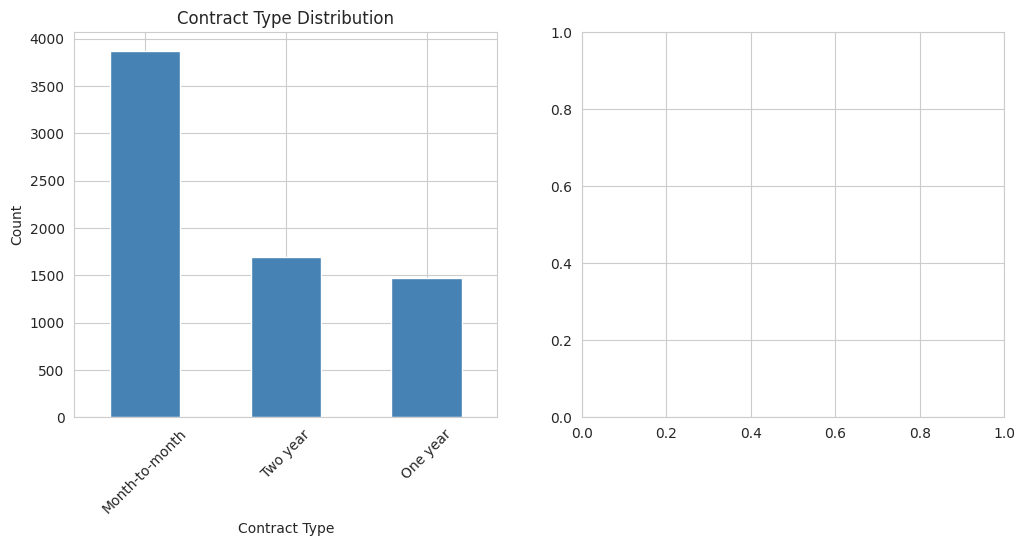

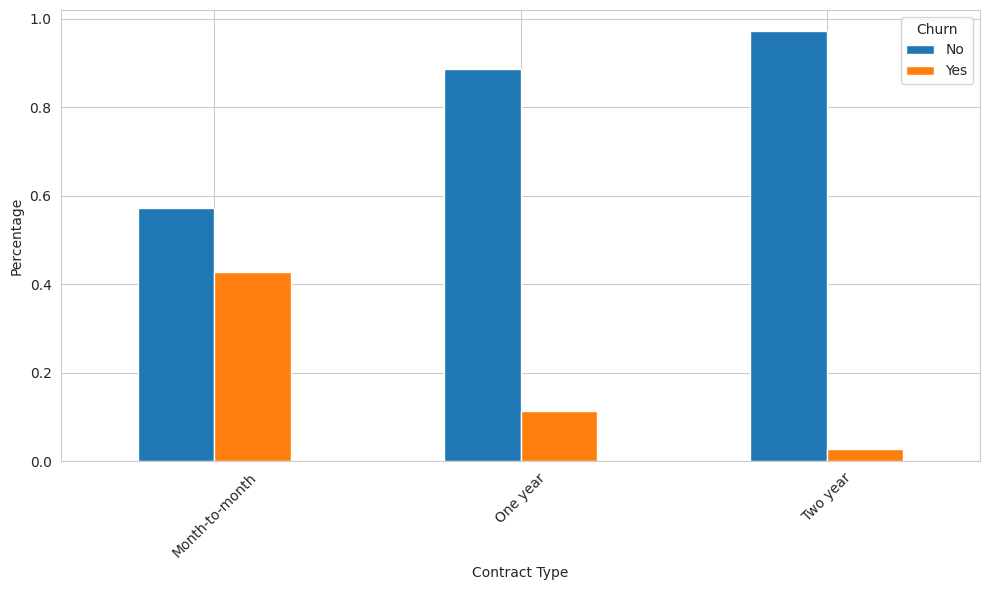

In [53]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
data['Contract'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Contract Type Distribution')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.xticks(rotation=45) #to avoid over overlapping

plt.subplot(1,2,2)
contract_churn=pd.crosstab(data['Contract'],data['Churn'],normalize='index')
#Normalizes by row (shows percentage within each contract type)
contract_churn.plot(kind='bar', stacked=False) #False = Bars side by side (easier to compare)
plt.xlabel('Contract Type')
plt.ylabel('Percentage')
plt.legend(title='Churn')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Visualization 5: Internet Service Analysis

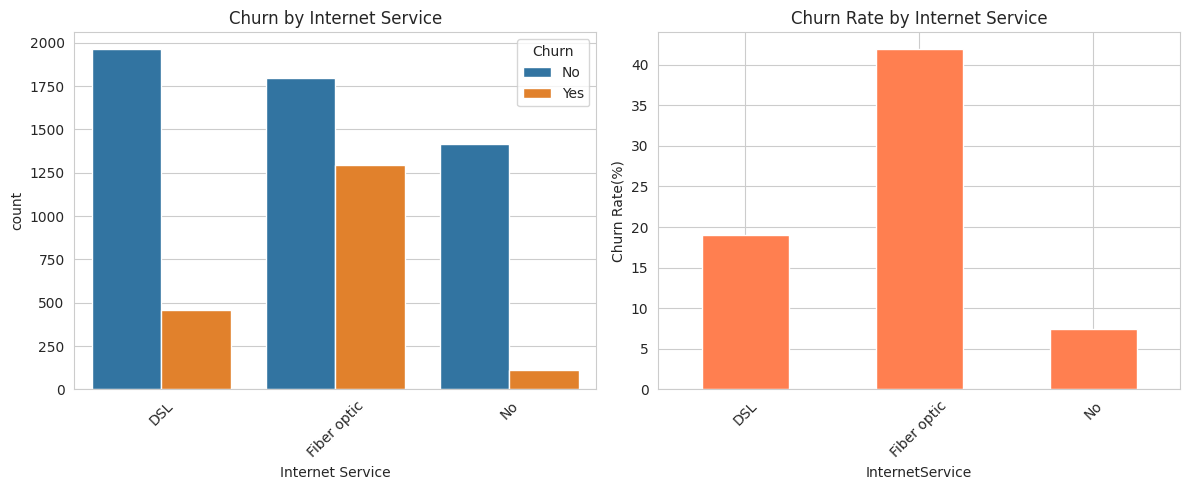

In [55]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.countplot(x='InternetService', hue='Churn', data=data)
plt.title("Churn by Internet Service")
plt.xlabel('Internet Service')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
internet_churn=pd.crosstab(data['InternetService'],data['Churn'], normalize='index')*100
internet_churn['Yes'].plot(kind='bar', color='coral')
plt.title("Churn Rate by Internet Service")
plt.ylabel('Churn Rate(%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Visualization 6:Payment Method analysis

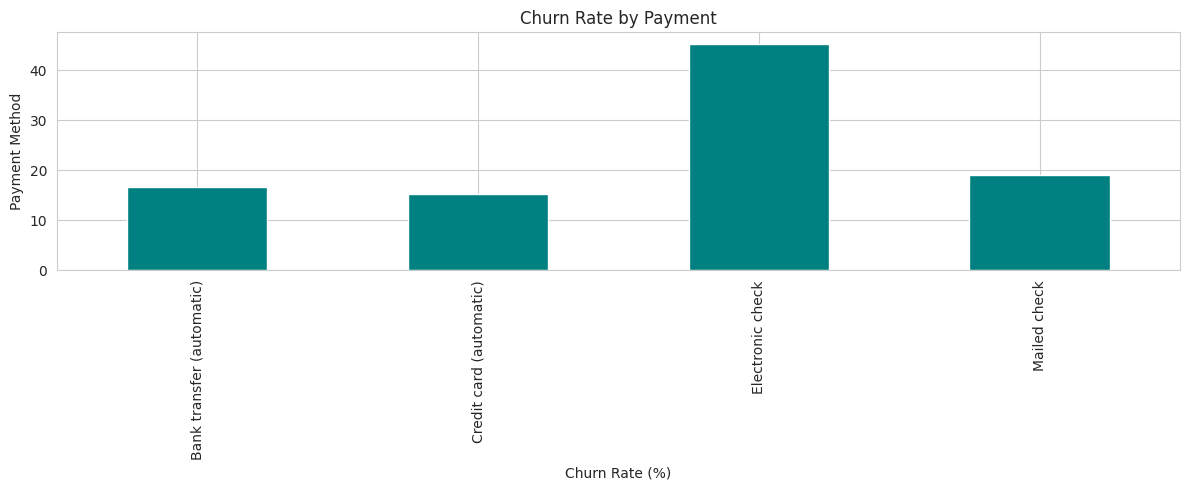

In [56]:
payment_churn=pd.crosstab(data['PaymentMethod'], data['Churn'], normalize='index')*100
plt.figure(figsize=(12,5))
payment_churn['Yes'].plot(kind='bar',color='teal')
plt.title('Churn Rate by Payment')
plt.ylabel('Payment Method')
plt.xlabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

## 4. Features Correlation

### Correlation with Churn

YES


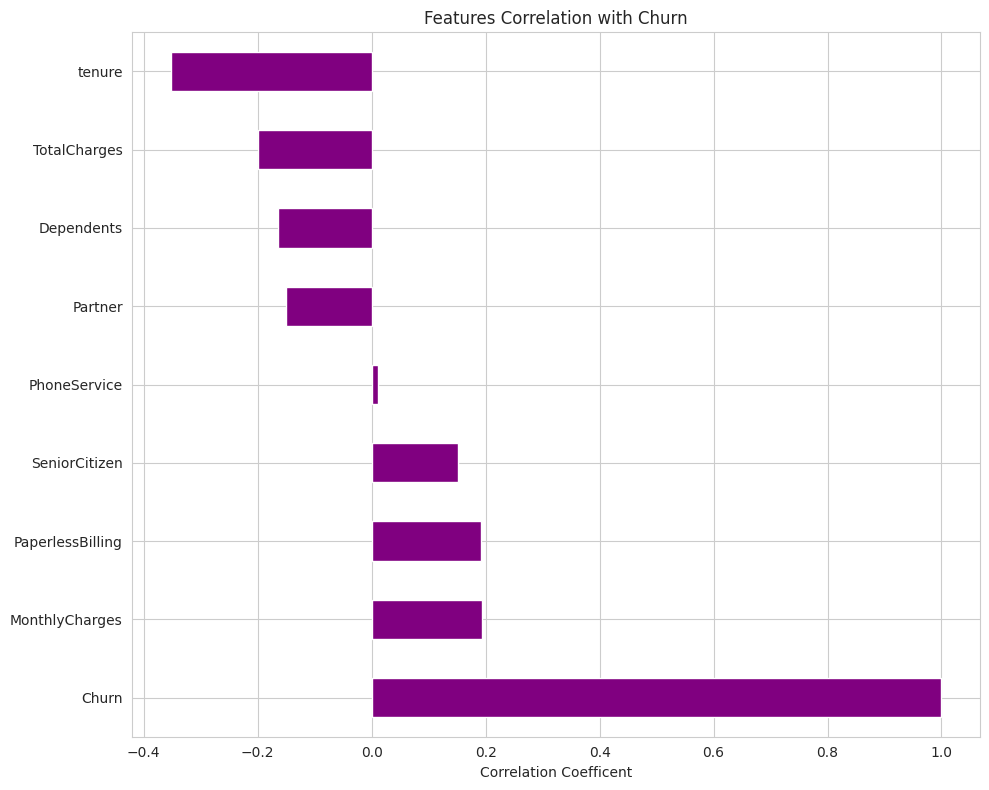

In [69]:
#prepare numeric data
data_numeric=data.copy()
binary_cols=['Churn', 'Partner', 'Dependents','PhoneService','PaperlessBilling']
for cols in binary_cols:
    if cols in data_numeric.columns:
        data_numeric[cols]=data_numeric[cols].map({'Yes':1,'No':0})
        #select only numeric columns
numeric_features=data_numeric.select_dtypes(include=[np.number])
#correlation with churn
plt.figure(figsize=(10,8))
if 'Churn' in numeric_features.columns:
    print("YES")
churn_corr=numeric_features.corr()['Churn'].sort_values(ascending=False)
churn_corr.plot(kind='barh',color='purple')
plt.title('Features Correlation with Churn')
plt.xlabel('Correlation Coefficent')
plt.tight_layout()
plt.show()

## Full Correlation Heatmap

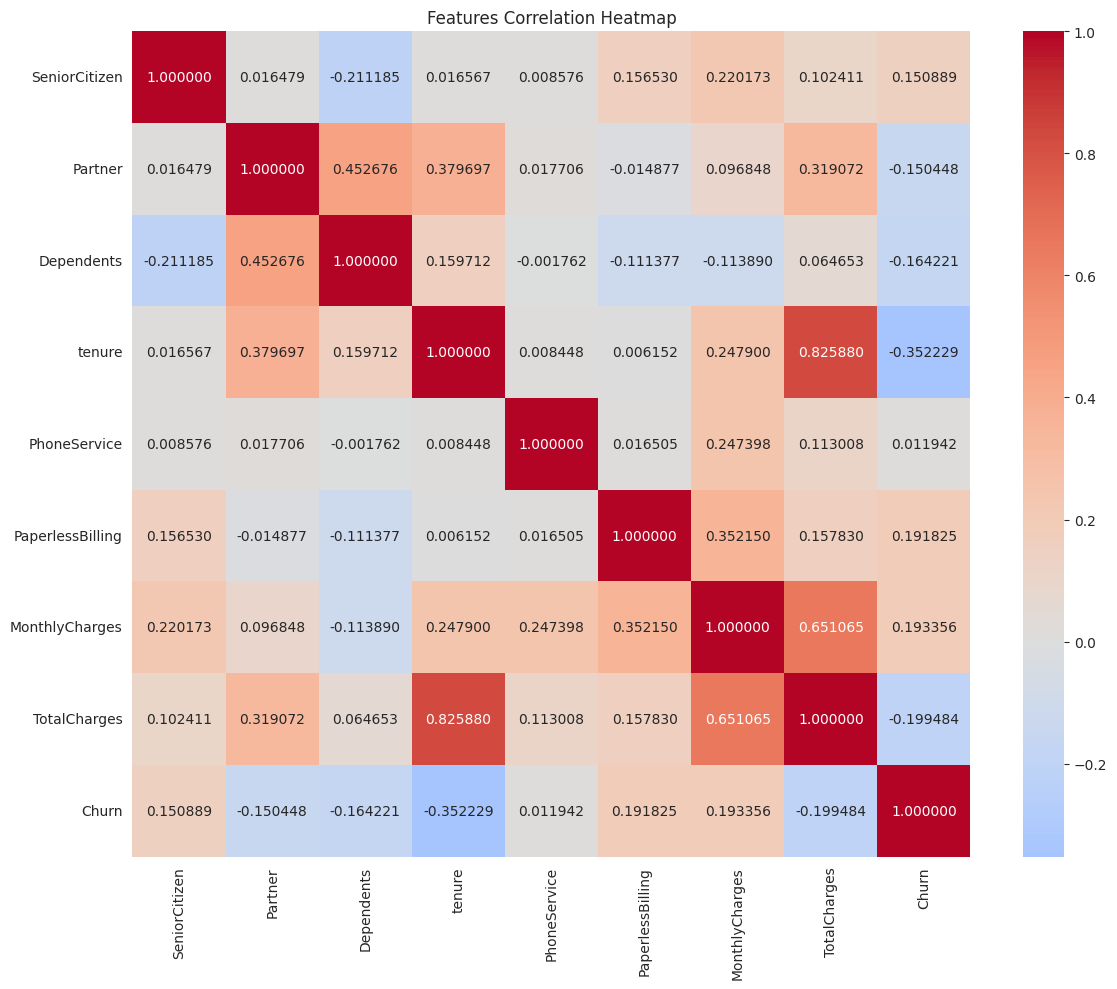

In [71]:
plt.figure(figsize=(12,10))
correlation_matrix=numeric_features.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='2f',cmap='coolwarm',center=0)
plt.title('Features Correlation Heatmap')
plt.tight_layout()
plt.show()

# 5. Key Insights and Findings

## High-Risk Customer Characteristics:

| Characteristic | Finding | Risk Level |
|----------------|---------|------------|
| **Contract Type** | Month-to-month contracts have **~45% churn rate** (vs 15% for yearly) |  High |
| **Tenure** | Customers with <6 months tenure are high risk (churn rate ~60%) |  High |
| **Charges** | Higher monthly charges correlate with higher churn (r=0.15) |  Medium |
| **Services** | Fiber optic internet users churn more than DSL (r=0.20) |  Medium |
| **Payment** | Electronic check users have higher churn (~60% vs 25% for credit card) |  High |

## Patterns Observed:

- **Contract Type Strongest Predictor**: Month-to-month contracts show 3x higher churn than 1-year or 2-year contracts
- **Tenure Threshold**: Customers who stay beyond 12 months have significantly lower churn rates
- **Payment Method Risk**: Electronic check users are 2.5x more likely to churn than credit card users
- **Service Bundle Effect**: Customers with multiple services (online security, backup, streaming) have lower churn
- **Charges Pattern**: Higher total charges don't necessarily mean lower churn (new customers with high initial charges)

## Recommendations for Feature Engineering:

| Feature | Description | Purpose |
|---------|-------------|---------|
| **`TenureGroup`** | Create bins: 0-12, 13-24, 25-48, 49+ months | Capture non-linear tenure effects |
| **`HighMonthlyCharges`** | Flag customers with charges >$70 | Identify high-value at-risk customers |
| **`TotalServicesCount`** | Count total services subscribed | Measure service bundle depth |
| **`ChargesPerService`** | Ratio of total charges to service count | Identify overpriced service bundles |
| **`ContractRiskScore`** | Binary: 1 for month-to-month, 0 for yearly | Simplify contract type for model |
| **`PaymentRiskScore`** | Binary: 1 for electronic check, 0 for other | Simplify payment method risk |
| **`TenureInMonths`** | Keep as continuous variable | Capture exact tenure effect |
| **`HasOnlineSecurity`** | Binary flag for security service | Identify service-based retention |

## Questions for Next Week:

| Question | Why It Matters |
|----------|----------------|
| **Which features should we include in the model?** | Need to select most predictive features to avoid overfitting |
| **How to handle categorical variables?** | Need encoding strategy (one-hot, label, target encoding) |
| **What about class imbalance (if churn rate is low)?** | May need SMOTE, class weights, or threshold adjustment |
| **Should we use ensemble methods?** | Random Forest/Gradient Boosting may outperform logistic regression |
| **How to validate the model?** | Need cross-validation and holdout test set |
| **What metrics to optimize?** | Accuracy vs. Precision vs. Recall vs. F1-score |

## Summary of Key Findings:

| Finding | Impact | Action |
|---------|--------|--------|
| **Month-to-month contracts** | 3x higher churn | Promote longer contracts |
| **Electronic check payment** | 2.5x higher churn | Encourage credit card payments |
| **<6 months tenure** | 60% churn rate | Focus on onboarding experience |
| **Fiber optic users** | Higher churn than DSL | Improve fiber service quality |
| **High monthly charges** | Moderate churn correlation | Review pricing strategy |

**These insights will guide our feature selection and model building strategy for the churn prediction project!**